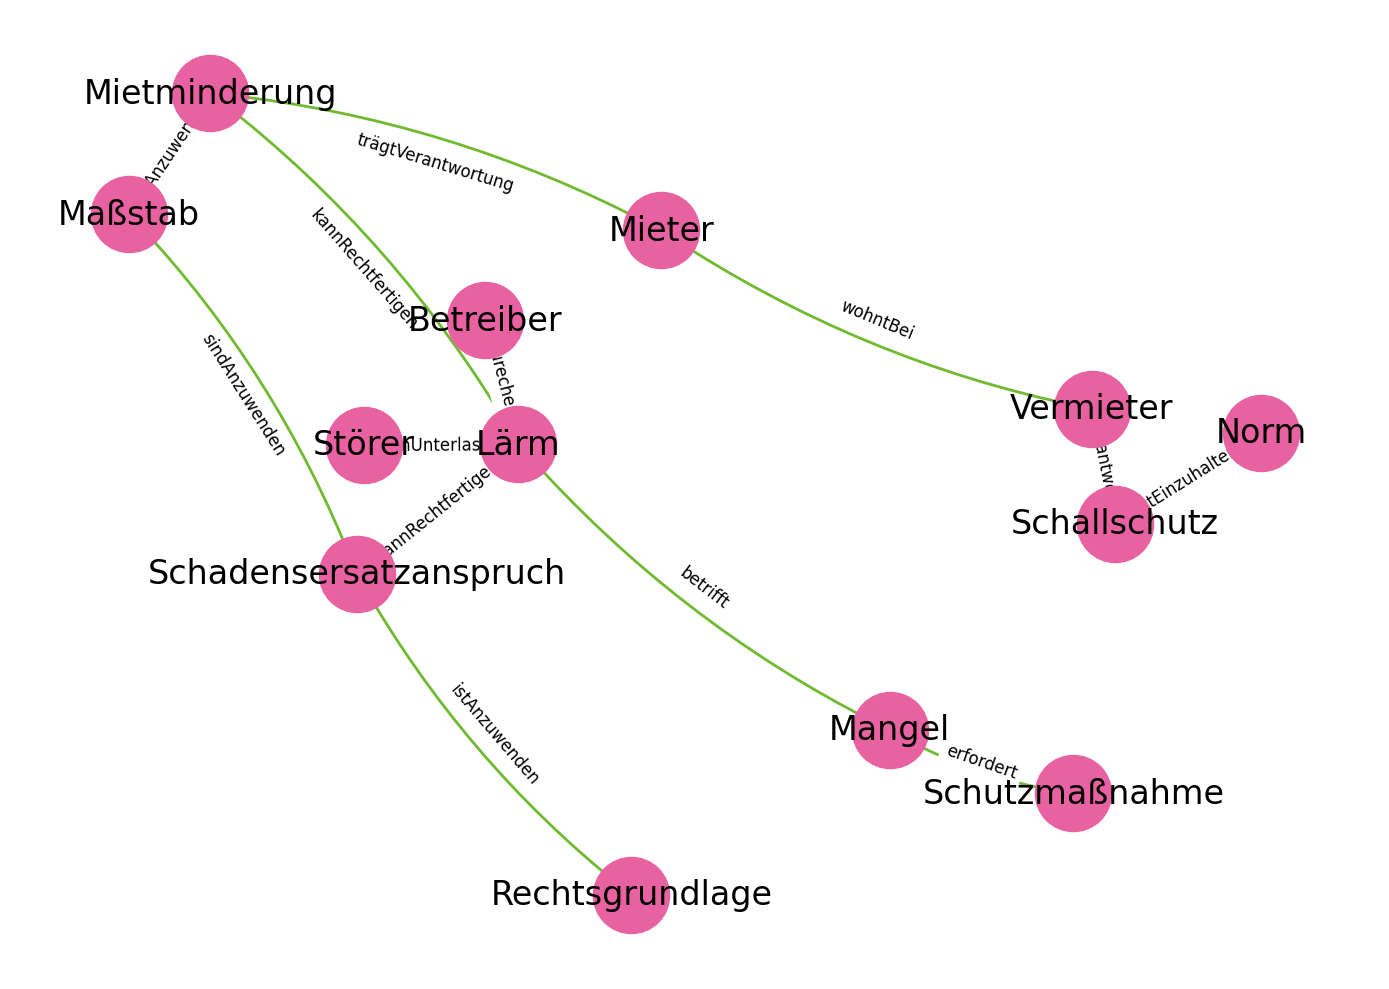

In [21]:
import json
import networkx as nx
import matplotlib.pyplot as plt

# --- Lade die Ontologie ---
with open("ontology_output/gcq_ontology_topdown_refined_with_keywords.json", encoding="utf-8") as f:
    ontology_data = json.load(f)

data = ontology_data["Cluster 8"]["refined_ontology"]

# --- Graph aufbauen ---
G = nx.DiGraph()
for node in data["classes"]:
    G.add_node(node)
for subj, pred, obj in data["relationships"]:
    G.add_edge(subj, obj, label=pred)

# --- Layout ---
pos = nx.spring_layout(G, k=0.9, iterations=100, seed=42)  # k steuert Abstand

# --- Zeichnen ---
plt.figure(figsize=(14, 10))  # größerer Canvas

# Knoten
nx.draw_networkx_nodes(G, pos, node_color="#E862A1", node_size=3000)

# Labels auf Knoten
nx.draw_networkx_labels(G, pos, font_size=24, font_color="black")

# Kanten
nx.draw_networkx_edges(G, pos, edge_color="#70BA30", arrows=True, width=2, connectionstyle="arc3,rad=0.1")

# Kantentexte
edge_labels = nx.get_edge_attributes(G, 'label')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=12, label_pos=0.5)

plt.axis("off")
plt.tight_layout()
plt.show()



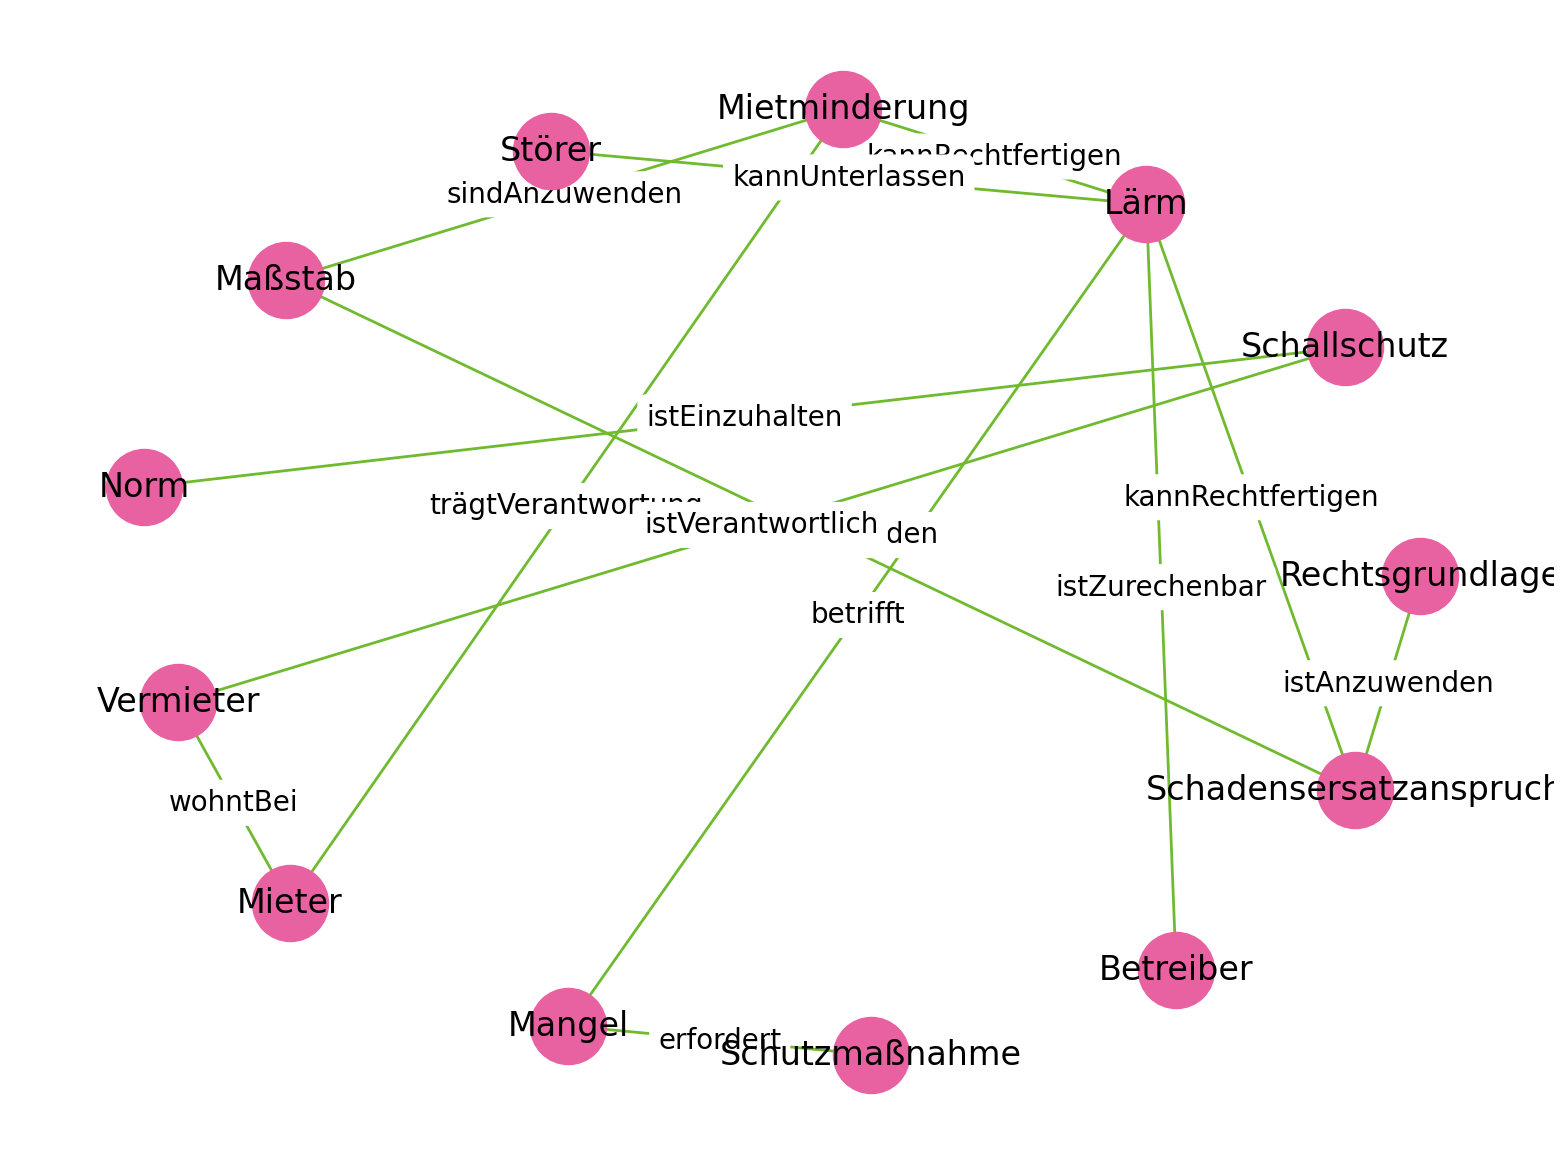

In [22]:
import json
import networkx as nx
import matplotlib.pyplot as plt

# --- Lade die Ontologie ---
with open("ontology_output/gcq_ontology_topdown_refined_with_keywords.json", encoding="utf-8") as f:
    ontology_data = json.load(f)

data = ontology_data["Cluster 8"]["refined_ontology"]

# --- Graph aufbauen ---
G = nx.DiGraph()
for node in data["classes"]:
    G.add_node(node)
for subj, pred, obj in data["relationships"]:
    G.add_edge(subj, obj, label=pred)

# --- Layout ---
# k etwas größer für mehr Abstand, evtl. iterations erhöhen
pos = nx.spring_layout(G, k=12, iterations=200, seed=10)

# --- Zeichnen ---
plt.figure(figsize=(16, 12))

# Knoten
nx.draw_networkx_nodes(G, pos,
                       node_color="#E862A1",
                       node_size=3000)

# Node-Labels
nx.draw_networkx_labels(G, pos,
                        font_size=24,
                        font_color="black")

# Kanten mit geradem Verlauf und Pfeilspitzen
nx.draw_networkx_edges(G, pos,
                       edge_color="#70BA30",
                       arrows=True,
                       arrowstyle='-|>',
                       arrowsize=26,
                       width=2,
                          style='solid',

                       connectionstyle="arc3,rad=0")  # rad=0 → komplett gerade

# Kantentexte größer und horizontal ausgerichtet
edge_labels = nx.get_edge_attributes(G, 'label')
nx.draw_networkx_edge_labels(G, pos,
                             edge_labels=edge_labels,
                             font_size=20,
                             label_pos=0.5,
                             rotate=False)  # rotate=False verhindert schiefe Texte

plt.axis("off")
plt.tight_layout(pad=2)  # mehr Außenabstand
plt.show()


TypeError: draw_networkx_nodes() got an unexpected keyword argument 'zorder'

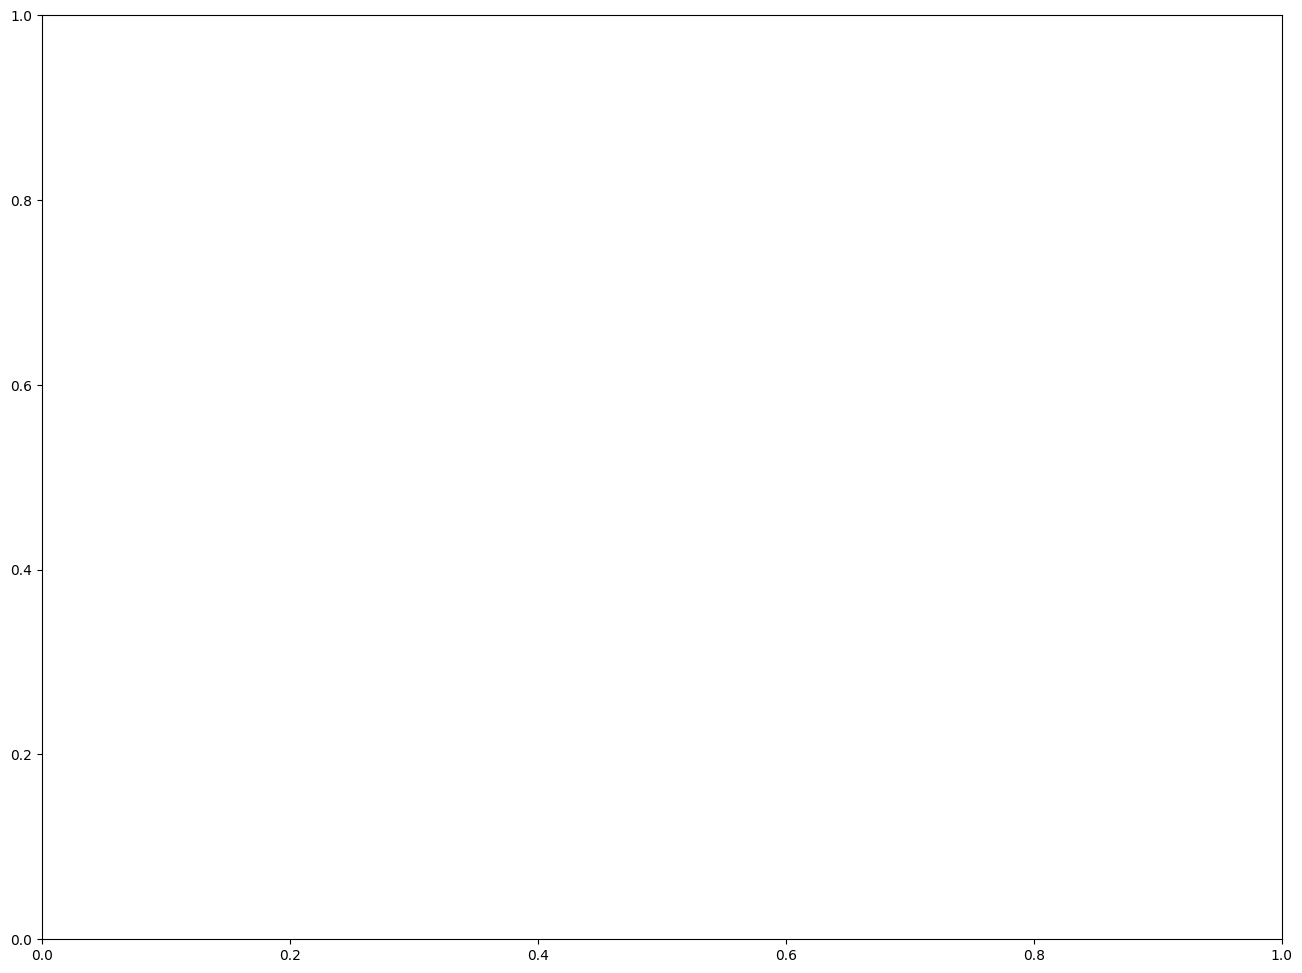

In [23]:
import json
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch

# --- Lade die Ontologie ---
with open("ontology_output/gcq_ontology_topdown_refined_with_keywords.json", encoding="utf-8") as f:
    ontology_data = json.load(f)
data = ontology_data["Cluster 8"]["refined_ontology"]

# --- Graph aufbauen ---
G = nx.DiGraph()
for n in data["classes"]:
    G.add_node(n)
for subj, pred, obj in data["relationships"]:
    G.add_edge(subj, obj, label=pred)

# --- Layout ---
pos = nx.spring_layout(G, k=12, iterations=200, seed=10)

# --- Zeichnen ---
fig, ax = plt.subplots(figsize=(16, 12))
  
# 1) Knoten
nx.draw_networkx_nodes(
    G, pos,
    node_color="#E862A1",
    node_size=3000,
    ax=ax,
    zorder=2
)

# 2) Node-Labels
nx.draw_networkx_labels(
    G, pos,
    font_size=24,
    font_color="black",
    ax=ax,
    zorder=3
)

# 3) Kanten als FancyArrowPatch (shrinkB stellt sicher, dass die Pfeilspitze nicht unter dem Knoten verschwindet)
for u, v, data_edge in G.edges(data=True):
    src = pos[u]
    dst = pos[v]
    arrow = FancyArrowPatch(
        src, dst,
        arrowstyle='-|>',          # normaler Pfeil mit Spitze
        mutation_scale=20,         # Größe der Pfeilspitze
        color="#70BA30",
        linewidth=2,
        shrinkA=0,                 # keine Kürzung am Start
        shrinkB=20,                # kürzt die Linie am Ziel um 20 Punkte (passt zur Knotengröße)
        zorder=1
    )
    ax.add_patch(arrow)

# 4) Kantentexte
edge_labels = nx.get_edge_attributes(G, 'label')
nx.draw_networkx_edge_labels(
    G, pos,
    edge_labels=edge_labels,
    font_size=24,
    label_pos=0.5,
    rotate=False,
    ax=ax,
    zorder=4
)

ax.set_axis_off()
plt.tight_layout(pad=2)
plt.show()


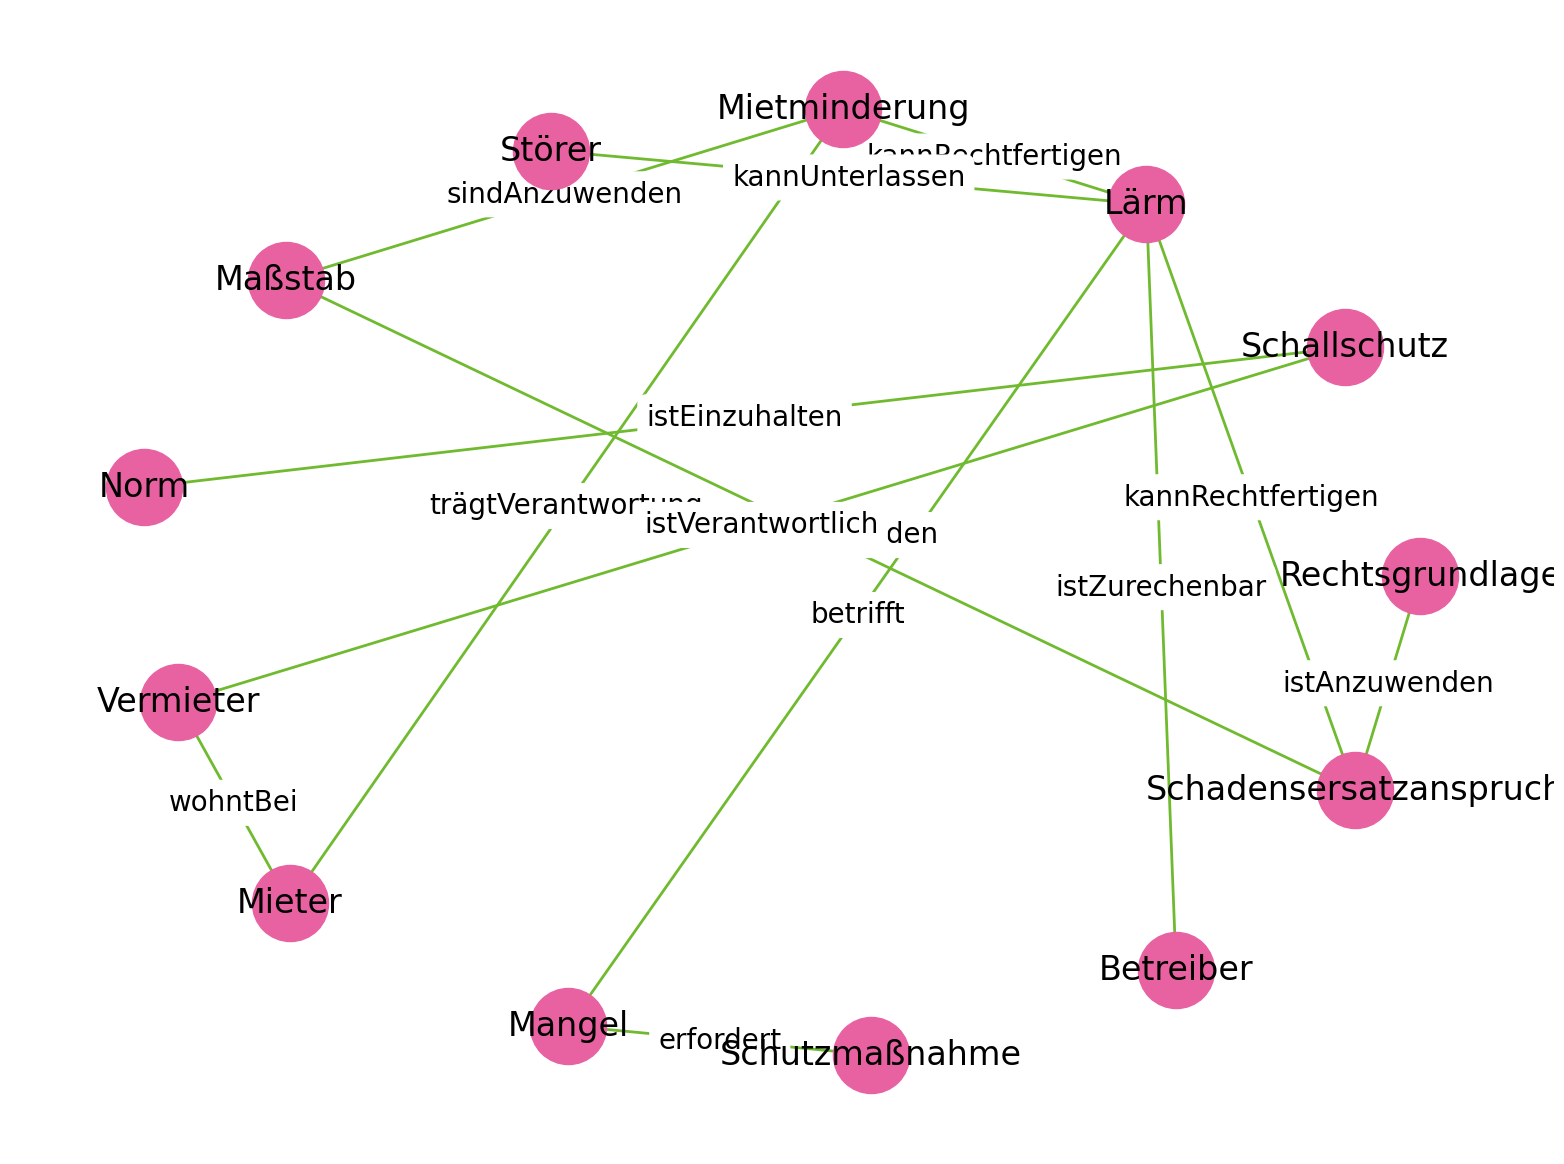

In [28]:
import json
import networkx as nx
import matplotlib.pyplot as plt

# --- Lade die Ontologie ---
with open("ontology_output/gcq_ontology_topdown_refined_with_keywords.json", encoding="utf-8") as f:
    ontology_data = json.load(f)

data = ontology_data["Cluster 8"]["refined_ontology"]

# --- Graph aufbauen ---
G = nx.DiGraph()
for node in data["classes"]:
    G.add_node(node)
for subj, pred, obj in data["relationships"]:
    G.add_edge(subj, obj, label=pred)

# --- Layout berechnen ---
pos = nx.spring_layout(G, k=12, iterations=200, seed=10)

# --- Zeichnen ---
plt.figure(figsize=(16, 12))

# 1) Nodes zuerst
nx.draw_networkx_nodes(
    G, pos,
    node_color="#E862A1",
    node_size=3000
)

# 2) Edges danach – mit Margins, damit die Pfeilspitze nicht in den Knoten hineinragt
nx.draw_networkx_edges(
    G, pos,
    edge_color="#70BA30",
    arrows=True,
    arrowstyle='-|>',
    arrowsize=26,
    width=2,
    style='solid',
    connectionstyle="arc3,rad=0",
    # Abstand von Quelle und Ziel zum tatsächlichen Knotenrand
    min_source_margin=10,
    min_target_margin=10
)

# 3) Node-Labels
nx.draw_networkx_labels(
    G, pos,
    font_size=24,
    font_color="black"
)

# 4) Edge-Labels
edge_labels = nx.get_edge_attributes(G, 'label')
nx.draw_networkx_edge_labels(
    G, pos,
    edge_labels=edge_labels,
    font_size=20,
    label_pos=0.5,
    rotate=False
)

plt.axis("off")
plt.tight_layout(pad=2)
plt.show()


C:\Users\cdoering\AppData\Local\Temp\ipykernel_16908\3056543605.py:34: UserWarning: 

The connectionstyle keyword argument is not applicable when drawing edges
with LineCollection.

To make this warning go away, either specify `arrows=True` to
force FancyArrowPatches or use the default values.
Note that using FancyArrowPatches may be slow for large graphs.

  nx.draw_networkx_edges(


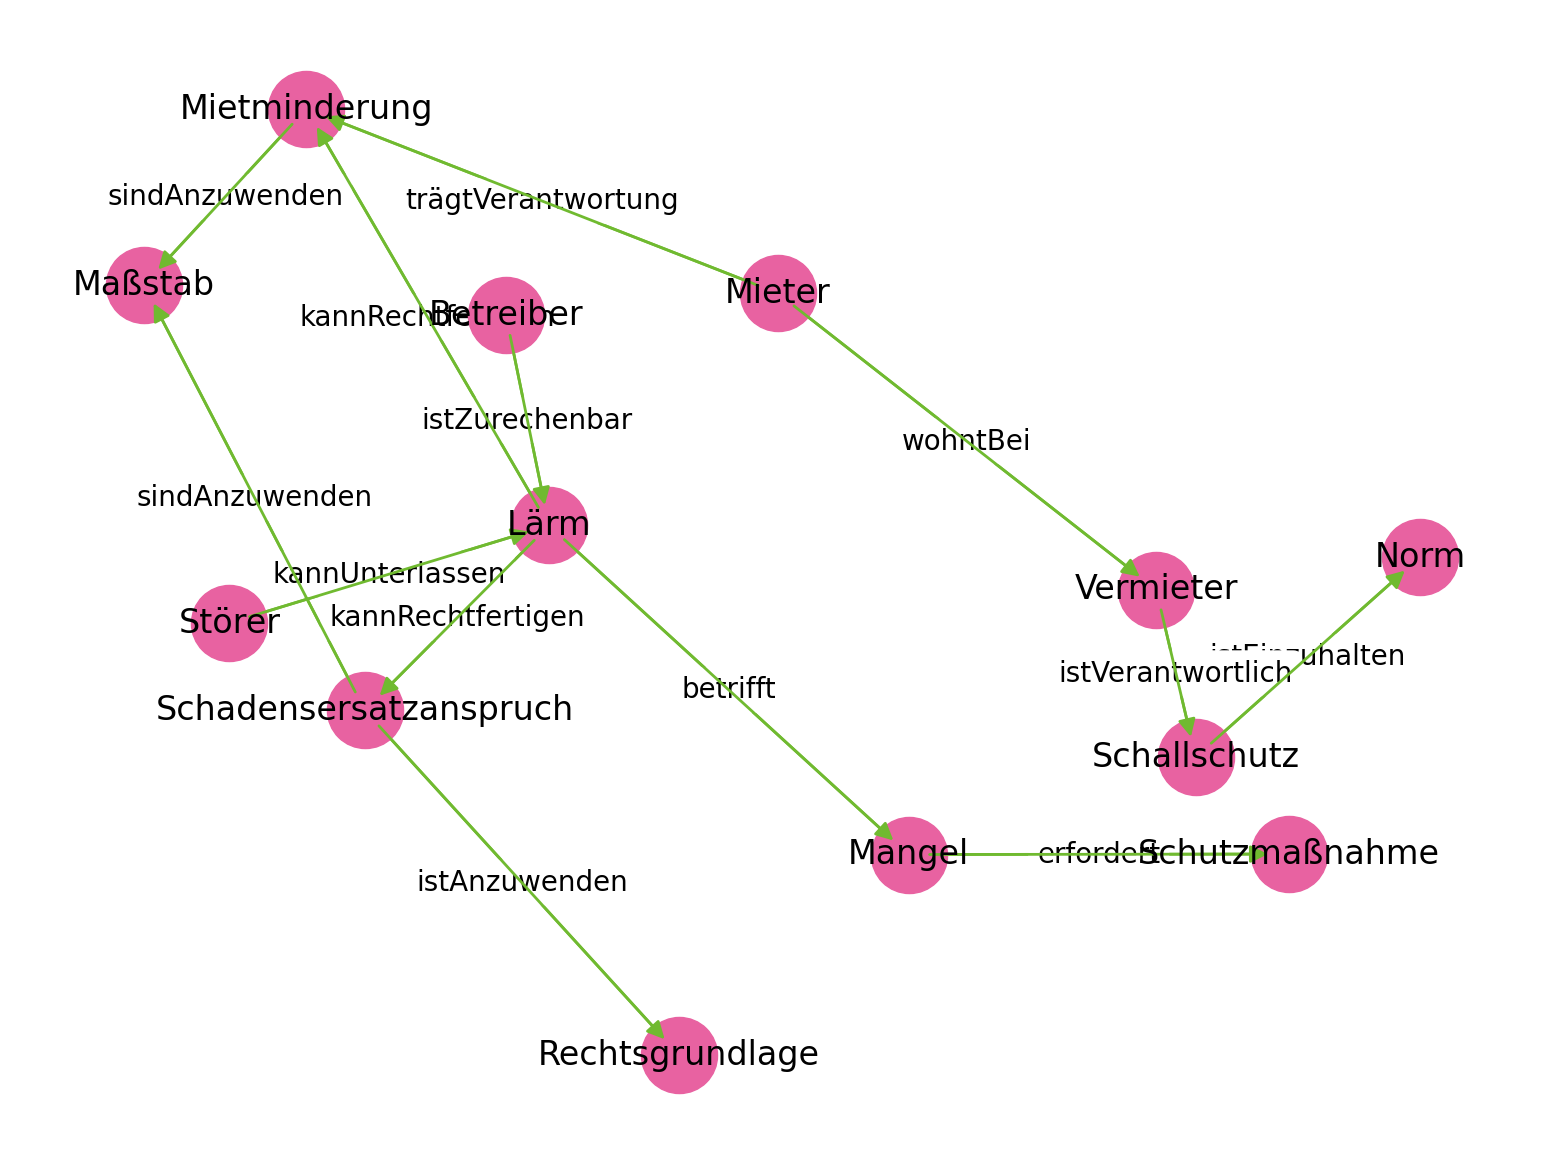

In [30]:
import json
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch

def show_graph_image_with_arrows_on_top(ontology, figsize=(16, 12), seed=42):
    """
    Zeichnet die verfeinerte Ontologie als reines Bild mit Matplotlib,
    wobei die Pfeilspitzen sicher oberhalb der Knoten liegen.
    """
    # --- Graph aufbauen ---
    G = nx.DiGraph()
    for node in ontology.get("refined_ontology", {}).get("classes", []):
        G.add_node(node)
    for subj, pred, obj in ontology.get("refined_ontology", {}).get("relationships", []):
        G.add_edge(subj, obj, label=pred)
    
    # --- Layout berechnen ---
    pos = nx.spring_layout(G, k=2.5, iterations=200, seed=seed)
    
    # --- Plot vorbereiten ---
    fig, ax = plt.subplots(figsize=figsize)
    ax.set_axis_off()
    
    # 1) Nodes
    nx.draw_networkx_nodes(
        G, pos,
        node_color="#E862A1",
        node_size=3000,
        ax=ax
    )
    
    # 2) Edges ohne Pfeilspitzen
    nx.draw_networkx_edges(
        G, pos,
        edge_color="#70BA30",
        arrows=False,
        width=2,
        connectionstyle="arc3,rad=0",
        ax=ax
    )
    
    # 3) Pfeilspitzen als FancyArrowPatch mit hohem zorder
    for u, v, data in G.edges(data=True):
        arrow = FancyArrowPatch(
            pos[u], pos[v],
            arrowstyle='-|>',
            mutation_scale=26,
            color="#70BA30",
            linewidth=2,
            connectionstyle="arc3,rad=0",
            shrinkA=15,    # Abstand vom Startknoten
            shrinkB=15,    # Abstand vom Zielknoten (Pfeilspitze)
            zorder=3       # höchste Ebene
        )
        ax.add_patch(arrow)
    
    # 4) Node-Labels
    nx.draw_networkx_labels(
        G, pos,
        font_size=24,
        font_color="black",
        ax=ax
    )
    
    # 5) Edge-Labels
    edge_labels = nx.get_edge_attributes(G, 'label')
    nx.draw_networkx_edge_labels(
        G, pos,
        edge_labels=edge_labels,
        font_size=20,
        label_pos=0.5,
        rotate=False,
        ax=ax
    )
    
    plt.tight_layout(pad=2)
    plt.show()

# --- Anwendung ---
if __name__ == "__main__":
    with open("ontology_output/gcq_ontology_topdown_refined_with_keywords.json", encoding="utf-8") as f:
        ontology_data = json.load(f)
    cluster8 = ontology_data["Cluster 8"]
    show_graph_image_with_arrows_on_top(cluster8)


In [32]:
pip install adjustText

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


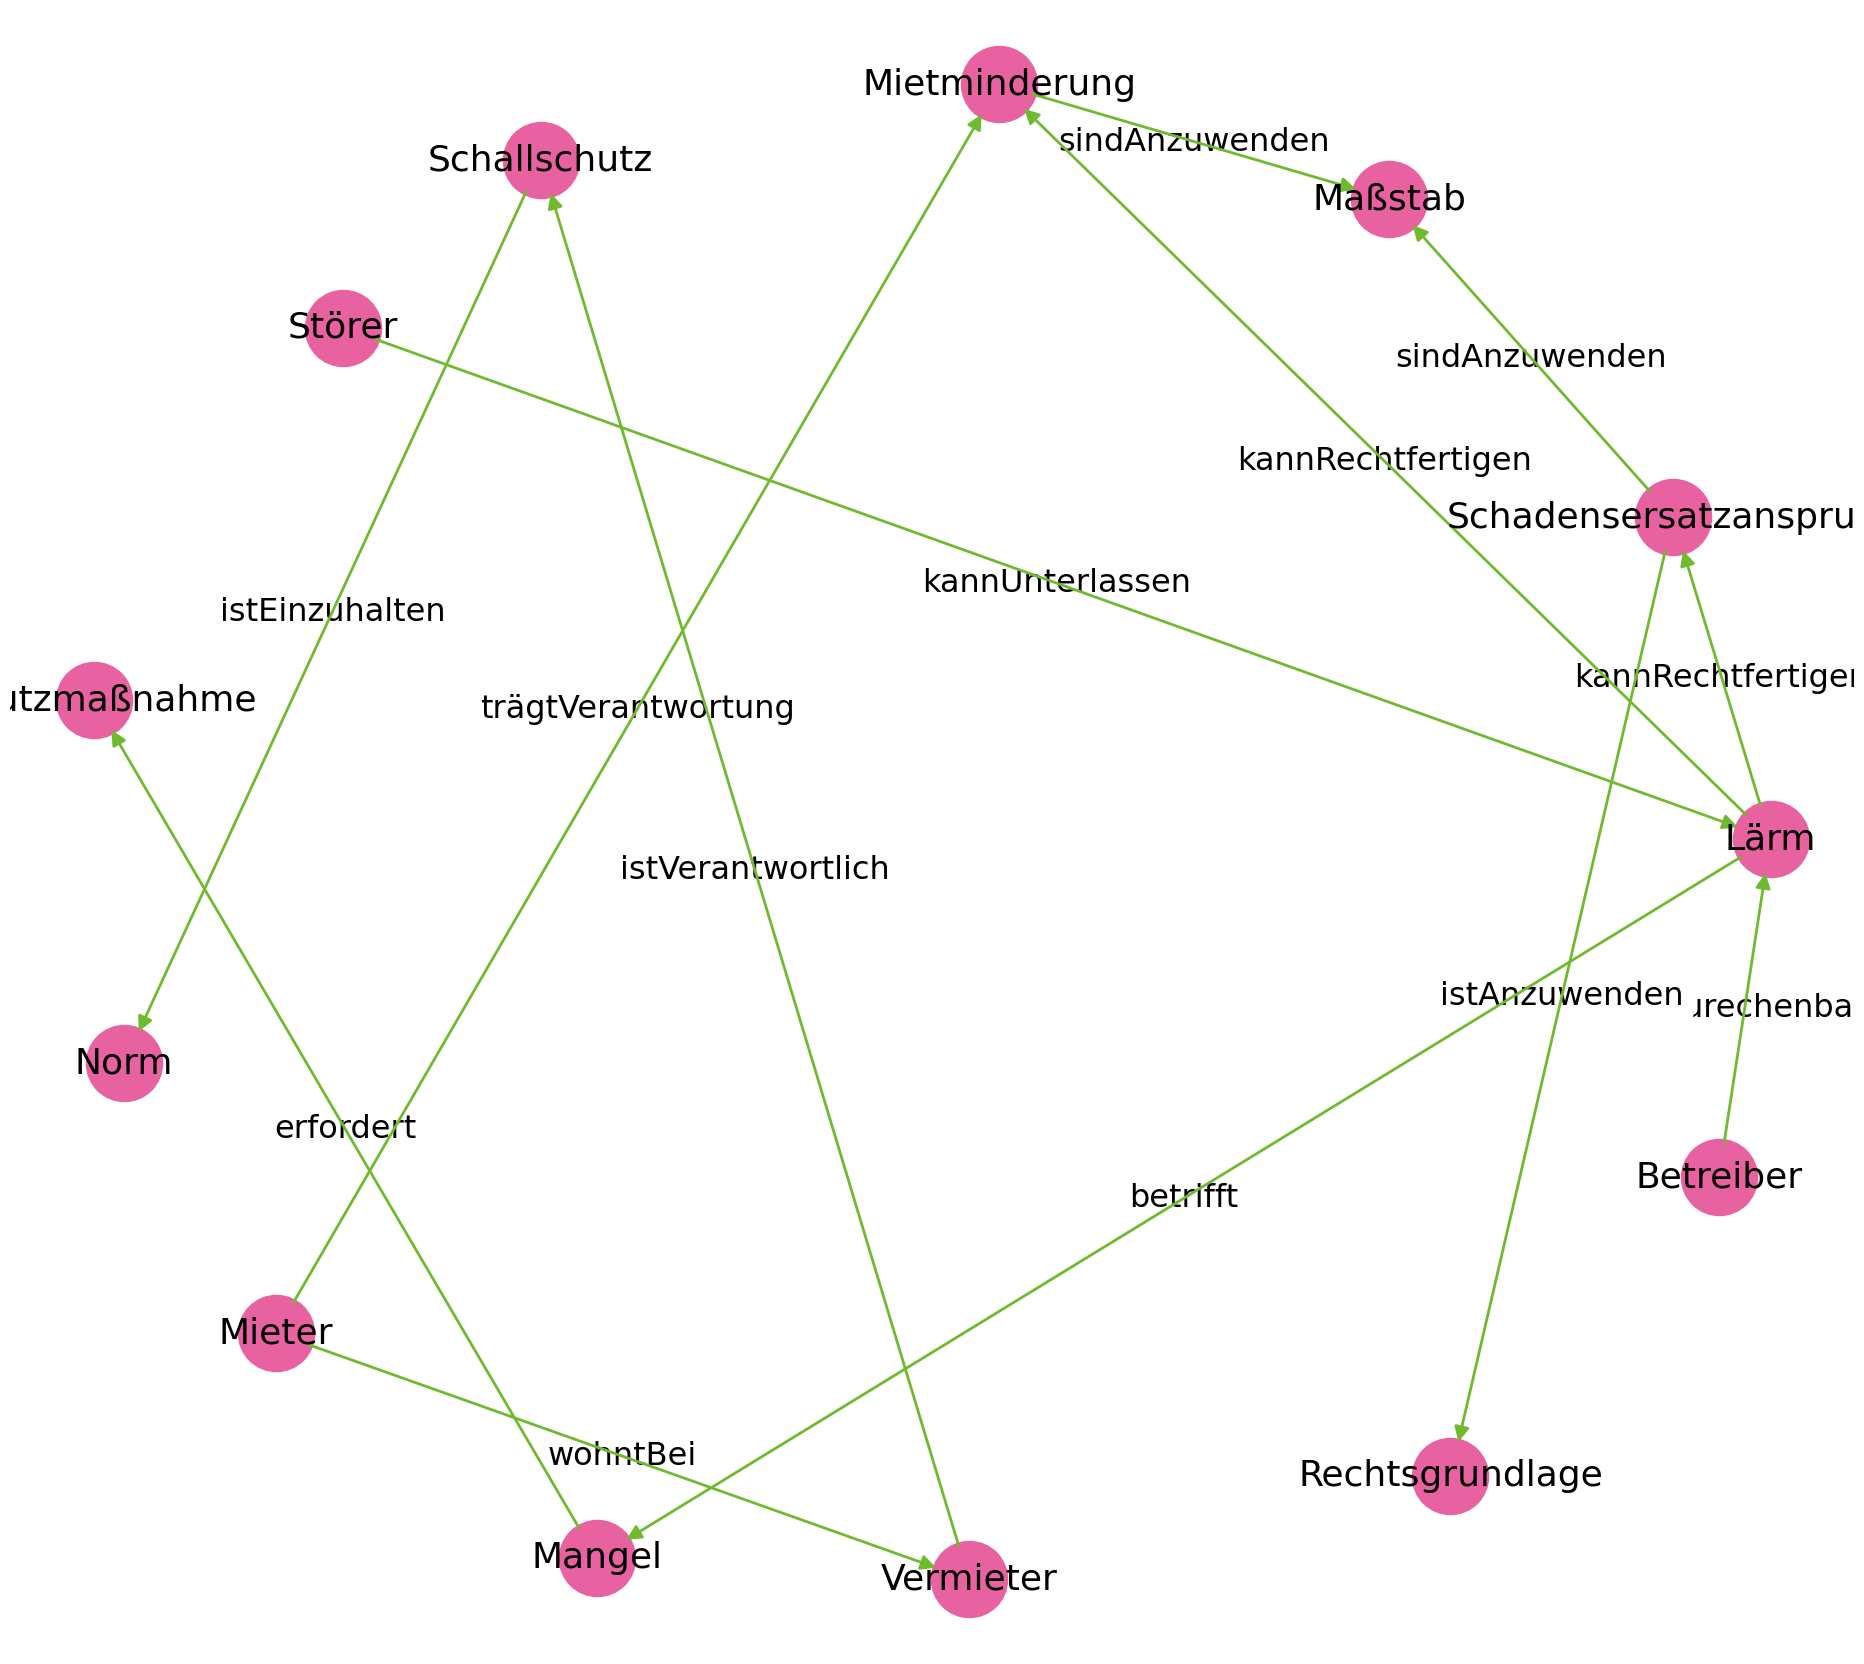

In [ ]:
import json
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch

def show_graph_image_with_arrows_on_top(ontology, figsize=(19, 17), seed=566):#566
    """
    Zeichnet die verfeinerte Ontologie als reines Bild mit Matplotlib,
    wobei Pfeilspitzen oberhalb der Knoten liegen, gestrichelte Redundanz entfernt
    und Knoten weiter auseinander stehen.Die wörter dürfen sich nicht überlappen. nie. alle wörter müssen voll lesbar sei.
    Der rosa kreis darf nicht über den wörtern auf den linien liegen.
    """
    # --- Graph aufbauen ---
    G = nx.DiGraph()
    for node in ontology.get("refined_ontology", {}).get("classes", []):
        G.add_node(node)
    for subj, pred, obj in ontology.get("refined_ontology", {}).get("relationships", []):
        # Verhindere doppelte Kanten
        if not G.has_edge(subj, obj):
            G.add_edge(subj, obj, label=pred)
    
    # --- Layout berechnen (weiter auseinander mit groesseren k) ---
    pos = nx.spring_layout(
        G,
        k=12,              # groesserer k-Wert -> mehr Abstand
        iterations=300,
        seed=seed
    )
    # --- Plot vorbereiten ---
    fig, ax = plt.subplots(figsize=figsize)
    ax.set_axis_off()
    
    # 1) Nodes
    nx.draw_networkx_nodes(
        G, pos,
        node_color="#E862A1",
        node_size=3000,
        ax=ax
    )
    # 2) Pfeilspitzen als FancyArrowPatch mit hohem zorder und groesserem shrink
    for u, v, data in G.edges(data=True):
        arrow = FancyArrowPatch(
            pos[u], pos[v],
            arrowstyle='-|>',
            mutation_scale=22,               # kompakte Spitze
            color="#70BA30",
            linewidth=2,
            connectionstyle="arc3,rad=0", # leichte Biegung
            shrinkA=25,    # Abstand vom Startknoten
            shrinkB=25,    # Abstand vom Zielknoten
            zorder=3       # oberste Ebene
        )
        ax.add_patch(arrow)
    
    # 3) Node-Labels
    nx.draw_networkx_labels(
        G, pos,
        font_size=26,
        font_color="black",
        ax=ax
    )
    
    # 4) Edge-Labels (direkt am Kantenmittelpunkt)
    edge_labels = nx.get_edge_attributes(G, 'label')
    nx.draw_networkx_edge_labels(
        G, pos,
        edge_labels=edge_labels,
        font_size=23,
        label_pos=0.5,
        rotate=False,
        ax=ax
    )
    
    plt.tight_layout(pad=2)
    plt.show()

# --- Anwendung ---
if __name__ == "__main__":
    with open("ontology_output/gcq_ontology_topdown_refined_with_keywords.json", encoding="utf-8") as f:
        ontology_data = json.load(f)
    cluster8 = ontology_data.get("Cluster 8", {})
    show_graph_image_with_arrows_on_top(cluster8)
